# Logistic Regression Research Project

## Dataset Selection

Dataset: Airline Passenger Satisfaction

The dataset contains passenger feedback collected from airline customers. It includes demographic information, travel details, and ratings of airline services.

Total observations: 103,904  
Total features: ~24

Target Variable:
satisfaction

Classes:
Satisfied  
Neutral or Dissatisfied

This is a **binary classification problem** where the goal is to predict whether a passenger is satisfied with airline services.


## Real-World Context

The dataset belongs to the airline transportation industry and contains customer survey responses regarding flight experiences.

Airlines collect such data to improve service quality and understand factors that influence passenger satisfaction.

## Stakeholders

The model can be useful for:

Airline management teams  
Customer experience teams  
Service quality analysts  
Airline marketing departments

## Cost of Misclassification

False Positive:
Predicting a passenger is satisfied when they are actually dissatisfied may cause airlines to overlook service issues.

False Negative:
Predicting dissatisfaction when the passenger is satisfied may lead to unnecessary operational changes.

Therefore balancing precision and recall is important.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("/content/train.csv")


In [4]:
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [6]:
df.shape


(103904, 25)

## Data Understanding

The dataset contains airline passenger information including demographic details, travel characteristics, and service ratings.

The objective is to predict passenger satisfaction using these features.

Industry Domain:
Airline transportation

Prediction Task:
Binary classification

Target Variable:
satisfaction

Classes:
Satisfied
Neutral/Dissatisfied

In [7]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [9]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000



## Problem Statement

Passenger satisfaction is an important metric for airlines as it directly affects customer retention, brand reputation, and revenue.

This project aims to develop a predictive model that classifies whether a passenger is satisfied with airline services.

Target Variable:
satisfaction

Classes:
1 = Satisfied  
0 = Neutral or Dissatisfied

In [20]:
df['satisfaction'].value_counts()

,count
satisfaction,
0,58879
1,45025


In [21]:
df['satisfaction'].value_counts(normalize=True)

,proportion
satisfaction,
0,0.566667
1,0.433333


## Class Distribution Analysis

The target variable "satisfaction" contains two classes:

0 → Neutral or Dissatisfied  
1 → Satisfied

Class counts:

Neutral/Dissatisfied: 58,879  
Satisfied: 45,025

Proportion:

Neutral/Dissatisfied: 56.7%  
Satisfied: 43.3%

The dataset is relatively balanced, meaning logistic regression can be applied without severe class imbalance issues.

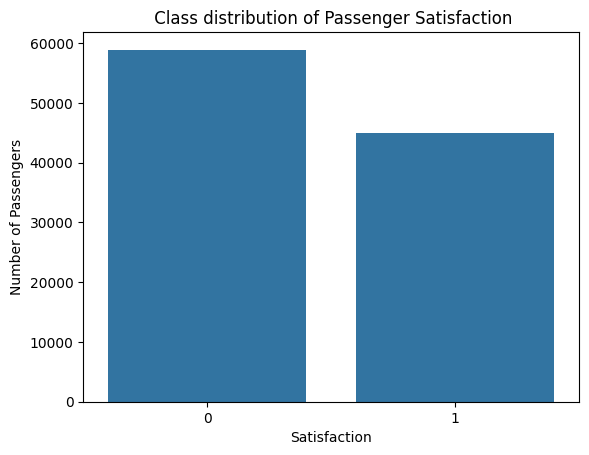

In [22]:
# Class Distribution Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['satisfaction'])

plt.title(" Class distribution of Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
plt.show()

The class distribution plot visually confirms that the dataset contains slightly more dissatisfied passengers than satisfied passengers, but the difference is not extreme. This balanced distribution helps prevent classification bias during model training.

In [14]:
# Missing values check
df.isnull().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


## Missing Value Strategy 1: Row Removal

The column "Arrival Delay in Minutes" contains 310 missing values.  
Since this represents less than 1% of the dataset, removing these rows is unlikely to significantly affect model performance.

After removing rows with missing values, the dataset size slightly decreases.

In [17]:
# Remove Missing Rows
df_drop=df.dropna()
df_drop.shape

(103594, 25)

Strategy 2 - Mean Imputation

In [23]:
df_fill = df.copy()

df_fill['Arrival Delay in Minutes'] = df_fill['Arrival Delay in Minutes'].fillna(
    df_fill['Arrival Delay in Minutes'].mean()
)

df_fill.isnull().sum()


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


### Comparison of Missing Value Strategies

Two strategies were evaluated:

Row Removal:
Removed 310 rows with missing values.

Mean Imputation:
Replaced missing values with the column mean while preserving all observations.

Since the proportion of missing values was very small (0.3%), both methods are acceptable. However, mean imputation was chosen for the final dataset because it preserves the full dataset size.


In [24]:
# Removing columns which are not useful for prediction
df_fill=df_fill.drop(columns=['Unnamed: 0','id'])
df_fill.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
# duplicate handling
df.duplicated().sum()

np.int64(0)

## Duplicate Detection

Duplicate records were checked to ensure that the dataset does not contain repeated observations that could bias the model.

The dataset was tested using the `duplicated()` function and no duplicate rows were found.

Therefore, no duplicate removal was required.

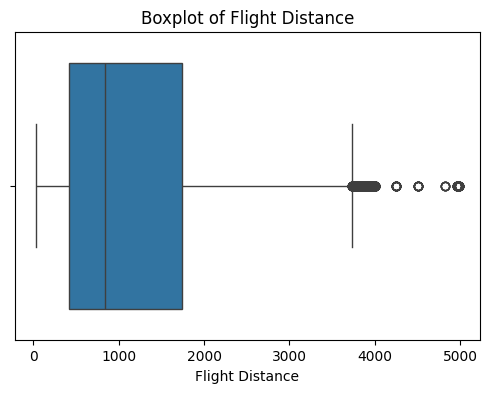

In [25]:
# Outlier detection
plt.figure(figsize=(6,4))

sns.boxplot(x=df_fill['Flight Distance'])

plt.title("Boxplot of Flight Distance")

plt.show()

## Outlier Detection — Flight Distance

The boxplot shows that most flights have distances below 2000 units.  
However, several observations appear beyond the upper whisker, indicating potential outliers.

These values correspond to very long-distance flights. Since long flights are realistic observations in airline data, these values are not necessarily errors.

Nevertheless, the IQR method will be used to formally identify outliers and evaluate their impact on model performance.

In [26]:
# IQR Outlier calculation
Q1 = df_fill['Flight Distance'].quantile(0.25)
Q3 = df_fill['Flight Distance'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-1579.5), np.float64(3736.5))

### IQR Outlier Detection

Q1 = 413  
Q3 = 1744  

IQR = Q3 - Q1

Calculated thresholds:

Lower Bound = -1579.5  
Upper Bound = 3736.5

Since flight distance cannot be negative, only the upper bound is relevant. Flights with distance greater than 3736.5 are considered potential outliers.

In [27]:
outliers = df_fill[df_fill['Flight Distance'] > upper_bound]

outliers.shape

(2291, 23)

### Number of Outliers

Using the IQR rule, 2,291 observations were identified as potential outliers in the "Flight Distance" variable.

This represents approximately 2.2% of the dataset.

These values correspond to very long-distance flights. Since long flights are realistic observations, they may represent legitimate data rather than measurement errors.

To evaluate their impact on model performance, a second dataset without these outliers will be created and later compared with the original dataset.

In [28]:
df_no_outliers = df_fill[df_fill['Flight Distance'] <= upper_bound]

df_no_outliers.shape

(101613, 23)

In [29]:
# Categorical feature encoding
df_fill.select_dtypes(include='object').columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')

## Categorical Feature Encoding

Logistic regression requires numerical input variables.  
Therefore categorical variables must be converted into numerical form.

The dataset contains four categorical variables:

Gender  
Customer Type  
Type of Travel  
Class

One-Hot Encoding was used to transform these variables into binary indicator variables.

This method avoids introducing artificial ordinal relationships between categories and improves model interpretability.

The parameter `drop_first=True` is used to avoid the dummy variable trap, which can cause multicollinearity.

In [30]:
df_encoded = pd.get_dummies(df_fill, drop_first=True)

df_encoded.shape

(103904, 24)

In [31]:
# Target separation
X = df_encoded.drop('satisfaction', axis=1)

y = df_encoded['satisfaction']

X.shape, y.shape

((103904, 23), (103904,))

In [33]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled.shape

(103904, 23)

## Feature Scaling

Feature scaling was applied using StandardScaler.

Standardization transforms each feature so that it has a mean of 0 and a standard deviation of 1.

 Scaling ensures that all features contribute equally during model training and improves convergence speed.

In [34]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((83123, 23), (20781, 23))

## Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split.

Training data (80%) is used to train the Logistic Regression model.  
Testing data (20%) is used to evaluate model performance on unseen data.

A fixed random seed (random_state=42) was used to ensure reproducibility of the experiment.

#Train the Logistic Regression Model

In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred=model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.8766180645782204

In [41]:
from sklearn.metrics import precision_score
precision_score(y_test,y_pred)

0.8733639494833525

In [42]:
from sklearn.metrics import recall_score
recall_score(y_test,y_pred)

0.8388839876488752

In [43]:
from sklearn.metrics import f1_score
f1_score(y_test,y_pred)


0.8557768027899652

In [44]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[10610,  1103],
       [ 1461,  7607]])

In [46]:
y_prob = model.predict_proba(X_test)[:, 1]

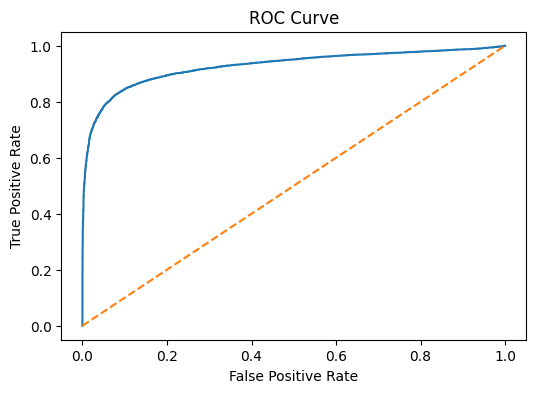

In [48]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [49]:
roc_auc_score(y_test, y_prob)

np.float64(0.9274498800924372)

## ROC-AUC Result

The Logistic Regression model achieved a ROC-AUC score of **0.927**.

This indicates excellent classification performance. The model has a strong ability to distinguish between satisfied and dissatisfied passengers.

An AUC close to 1 suggests that the model ranks positive cases (satisfied passengers) higher than negative cases most of the time.

In [50]:
# 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_scaled,y,cv=5)
cv_scores

array([0.87397142, 0.87353833, 0.87353833, 0.87464511, 0.87892204])

In [51]:
cv_scores.mean()

np.float64(0.8749230443389674)

## 5-Fold Cross Validation

To evaluate model stability, 5-fold cross validation was performed.

The dataset is divided into five subsets. The model is trained on four subsets and tested on the remaining subset. This process is repeated five times.

The final score is the average performance across all folds.

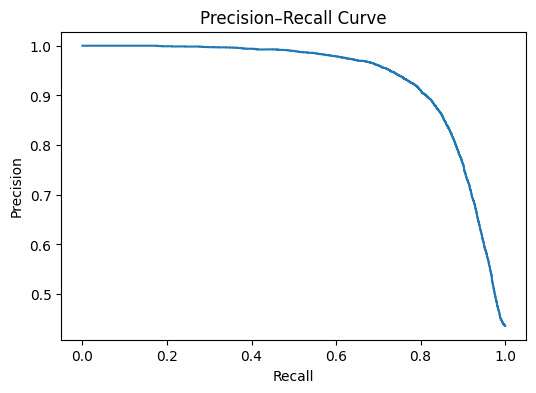

In [52]:
# Precision-Recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

## Precision–Recall Curve

The Precision–Recall curve illustrates the trade-off between precision and recall for different classification thresholds.

Precision measures how many predicted positive cases are actually correct, while recall measures how many actual positive cases were correctly identified.

This curve is particularly useful when evaluating classification models where the focus is on correctly identifying the positive class.

In [53]:
# Extract Logistic Regression Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.head()

,Feature,Coefficient
0,Age,-0.125281
1,Flight Distance,-0.017060
2,Inflight wifi service,0.514892
3,Departure/Arrival time convenient,-0.178307
4,Ease of Online booking,-0.204918


In [54]:
#sort features by importance
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
7,Online boarding,0.829238
2,Inflight wifi service,0.514892
13,Checkin service,0.406633
10,On-board service,0.396539
11,Leg room service,0.333205
15,Cleanliness,0.284262
16,Departure Delay in Minutes,0.161640
12,Baggage handling,0.157285
14,Inflight service,0.137818
8,Seat comfort,0.088820


In [55]:
#convert coefficients to odds ratio
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

coefficients.head(10)

,Feature,Coefficient,Odds_Ratio
7,Online boarding,0.829238,2.291572
2,Inflight wifi service,0.514892,1.673457
13,Checkin service,0.406633,1.501754
10,On-board service,0.396539,1.486670
11,Leg room service,0.333205,1.395433
15,Cleanliness,0.284262,1.328781
16,Departure Delay in Minutes,0.161640,1.175437
12,Baggage handling,0.157285,1.170329
14,Inflight service,0.137818,1.147767
8,Seat comfort,0.088820,1.092884


## Feature Importance and Odds Ratio Interpretation

Logistic regression coefficients represent the change in log-odds of the target variable.

To make interpretation easier, coefficients were converted into odds ratios using the exponential function.

Odds ratios greater than 1 indicate an increase in the probability of passenger satisfaction, while odds ratios less than 1 indicate a decrease in satisfaction likelihood.

In [56]:
# Logistic Regression with L2 Regularization
ridge_model = LogisticRegression(penalty='l2', max_iter=1000)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

accuracy_score(y_test, y_pred_ridge)

0.8766180645782204

In [57]:
# Logistic Regression with L1 Regularization
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

accuracy_score(y_test, y_pred_lasso)

0.8766180645782204

In [58]:
# Sensitivity Analysis
results = {}

for size in [0.6, 0.7, 0.8, 0.9]:

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_scaled, y, train_size=size, random_state=42
    )

    model_s = LogisticRegression(max_iter=1000)

    model_s.fit(X_train_s, y_train_s)

    y_pred_s = model_s.predict(X_test_s)

    results[size] = accuracy_score(y_test_s, y_pred_s)

results

{0.6: 0.8758240700640008,
 0.7: 0.8750802001796484,
 0.8: 0.8766180645782204,
 0.9: 0.8762390530266577}

## Conceptual Questions

### 1. What is the mathematical foundation of Logistic Regression?

Logistic Regression is based on the logistic function (sigmoid function), which transforms a linear combination of input features into a probability value between 0 and 1.

The model estimates the probability of the positive class using:

P(Y=1|X) = 1 / (1 + e^-(β0 + β1X1 + β2X2 + ... + βnXn))

The parameters (β) are estimated using Maximum Likelihood Estimation (MLE), which finds the parameter values that maximize the likelihood of observing the data.

---

### 2. Why do we use the sigmoid function?

The sigmoid function maps any real number into a value between 0 and 1.

This allows logistic regression to model probabilities for classification problems.

The output probability can then be converted into a class prediction using a threshold (commonly 0.5).

---

### 3. What are the assumptions of Logistic Regression?

Logistic Regression assumes:

1. The dependent variable is binary.
2. Observations are independent.
3. There is a linear relationship between the independent variables and the log-odds of the dependent variable.
4. There is little or no multicollinearity between predictor variables.
5. The dataset has a sufficiently large sample size.

---

### 4. When should Logistic Regression NOT be used?

Logistic Regression may not perform well when:

• The relationship between features and the target is highly nonlinear  
• There is severe multicollinearity between predictors  
• The dataset is extremely small  
• The classes are extremely imbalanced  
• The decision boundary is very complex

In such cases, models like Random Forest, SVM, or Neural Networks may perform better.

---

### 5. What happens if multicollinearity exists?

Multicollinearity occurs when independent variables are highly correlated.

Effects include:

• Unstable coefficient estimates  
• Increased variance of coefficients  
• Difficulty interpreting feature importance

Regularization techniques like Ridge or Lasso can help reduce the impact of multicollinearity.

---

### 6. Why does regularization reduce variance?

Regularization adds a penalty term to the loss function that discourages large coefficient values.

By limiting the magnitude of coefficients, the model becomes less sensitive to small fluctuations in the training data.

This reduces model variance and helps prevent overfitting.

---

### 7. What is the difference between L1 and L2 regularization?

L1 Regularization (Lasso):
Adds the absolute value of coefficients as a penalty term.

L1 tends to shrink some coefficients to zero, which effectively performs feature selection.

L2 Regularization (Ridge):
Adds the squared value of coefficients as a penalty term.

L2 shrinks coefficients but does not eliminate them entirely.

---

### 8. How are parameters estimated in Logistic Regression?

Logistic Regression parameters are estimated using Maximum Likelihood Estimation (MLE).

MLE finds the coefficient values that maximize the likelihood of observing the given training data.

Optimization algorithms such as gradient descent or quasi-Newton methods are typically used to solve this problem.

---

### 9. How do you handle class imbalance?

Class imbalance can be addressed using several techniques:

• Resampling the dataset (oversampling or undersampling)
• Using class weights in the logistic regression model
• Applying techniques like SMOTE
• Using evaluation metrics such as Precision, Recall, and F1-score instead of accuracy

---

### 10. How would you scale this model to 10 million rows?

To scale logistic regression to very large datasets:

• Use distributed computing frameworks like Spark MLlib  
• Apply stochastic gradient descent instead of batch optimization  
• Use efficient data storage formats such as Parquet  
• Perform feature selection or dimensionality reduction  
• Use parallel computing resources

### 11. How would you monitor this model in production?

When a Logistic Regression model is deployed in production, continuous monitoring is necessary to ensure that the model remains accurate and reliable over time.

Several aspects should be monitored:

**1. Prediction Performance**
Track evaluation metrics such as accuracy, precision, recall, F1-score, and ROC-AUC using newly observed labeled data. A decline in these metrics may indicate model degradation.

**2. Data Drift**
Monitor whether the distribution of input features changes over time. If the characteristics of passengers (e.g., flight distance, service ratings, travel type) change significantly from the training data, the model may become less reliable.

**3. Concept Drift**
Concept drift occurs when the relationship between features and the target variable changes. For example, passengers may start valuing different aspects of airline service over time, which could affect satisfaction prediction.

**4. Prediction Distribution**
Monitor the proportion of predicted classes. A sudden shift (e.g., predicting almost all passengers as satisfied) may indicate a problem in the model or input data.

**5. Data Quality Checks**
Ensure incoming data has no missing values, incorrect formats, or unexpected values that could cause incorrect predictions.

**6. Model Retraining**
Periodically retrain the model using new data so that it adapts to changing patterns in passenger behavior.

By continuously monitoring these aspects, organizations can maintain reliable model performance and quickly detect potential issues in production systems.